In [2]:
import polars as pl
import numpy as np
import xgboost as xgb
import os
from pathlib import Path
from tqdm import tqdm
import itertools
import json

In [3]:
data_dir = Path.home() / "teams/b13-domain-2/ca_data/"

X_train = pl.scan_parquet(data_dir / "X_train.parquet")
y_train = pl.scan_parquet(data_dir / "y_train.parquet")

X_test = pl.scan_parquet(data_dir / "X_test.parquet")
y_test = pl.scan_parquet(data_dir / "y_test.parquet")

X_validation = pl.scan_parquet(data_dir / "X_validation.parquet")
y_validation = pl.scan_parquet(data_dir / "y_validation.parquet")

In [4]:
xgb_clf = xgb.XGBClassifier(device="cuda", predictor="gpu_predictor", verbosity=1)

xgb_clf.load_model('final_xgb_1.ubj')

In [5]:
importance_scores = [float(x) for x in xgb_clf.feature_importances_]

feature_names = X_train.collect_schema().names()

feature_importance = dict(
    sorted(
        zip(feature_names, importance_scores),
        key=lambda x: x[1],
        reverse=True
    )
)

with open("ca_feature_importance.json", "w") as f:
    json.dump(feature_importance, f)

In [6]:
df = pl.concat([X_train, X_test, X_validation], how="vertical")
y = pl.concat([y_train, y_test, y_validation], how="vertical")

df = pl.concat([df, y], how="horizontal")

n = 10  # number of chunks

N = df.select(pl.len()).collect().item()
chunk = (N + n - 1) // n  # ceil

df_parts = df.drop("burned_area").with_columns([pl.all().cast(pl.Float32)]).collect(engine="streaming")

parts = [df_parts.slice(i * chunk, chunk) for i in range(n)]

del df_parts

In [7]:
y_pred_proba = []

threshold = 0.5 # default

for chunk in tqdm(parts):
    y_pred_proba.append(xgb_clf.predict_proba(chunk)[:, 1])

y_pred_proba = np.concatenate(y_pred_proba)
y_pred = (y_pred_proba >= threshold).astype(np.uint8)

del parts

100%|██████████| 10/10 [01:55<00:00, 11.54s/it]


In [8]:
df = (
    df.select(["lat", "lon", "year", "month", "burned_area"])
    .with_columns([
        pl.Series("y_pred_proba", y_pred_proba),
        pl.Series("y_pred", y_pred),
    ])
)

In [9]:
df_full = pl.scan_parquet(data_dir / 'ca_combined_data.parquet')

# Optimize storage types
df_full = (
    df_full
    .with_columns(pl.col('burned_area').cast(pl.UInt8))
    .with_columns(pl.col('month').cast(pl.UInt8))
    .with_columns(pl.col('year').cast(pl.UInt16))
    .with_columns(pl.col("landcover").cast(pl.UInt8))
)

df_full = df_full.with_columns(pl.col(pl.Float64).cast(pl.Float32))

# Drop null values
df_full = df_full.filter(
    ~(
        pl.any_horizontal(pl.all().is_null())
    )
)

# Lag inputs
df_full = df_full.sort(["lat", "lon", "year", "month"]).with_columns(
    pl.col("burned_area").shift(1).over(["lat", "lon"]).alias("burned_area")
).drop_nulls(subset=["burned_area"])

# Keep coordinates with max count
df_full = df_full.with_columns(
    pl.len().over(['lat', 'lon']).alias("group_len")
).filter(
    pl.col("group_len") == pl.col("group_len").max()
).drop("group_len")

# Remove burned_area
df_full = df_full.drop("burned_area")

# Convert landcover to string
landcover_class_names = {
    11: 'Open_Water',
    12: 'Perennial_Ice_Snow',
    21: 'Developed_Open_Space',
    22: 'Developed_Low_Intensity',
    23: 'Developed_Medium_Intensity',
    24: 'Developed_High_Intensity',
    31: 'Barren_Land',
    41: 'Deciduous_Forest',
    42: 'Evergreen_Forest',
    43: 'Mixed_Forest',
    51: 'Dwarf_Scrub',
    52: 'Shrub_Scrub',
    71: 'Grassland_Herbaceous',
    72: 'Sedge_Herbaceous',
    73: 'Lichens',
    74: 'Moss',
    81: 'Pasture_Hay',
    82: 'Cultivated_Crops',
    90: 'Woody_Wetlands',
    95: 'Emergent_Herbaceous_Wetlands'
}

df_full = df_full.with_columns(
    pl.col("landcover")
      .cast(pl.Int32)
      .replace_strict(landcover_class_names, default="UNKNOWN")
      .alias("landcover")
)

In [10]:
df_full = df_full.join(
    df,
    on=["lat", "lon", "year", "month"],
    how="left"
)

In [11]:
df_full.collect_schema()

Schema([('lat', Float32),
        ('lon', Float32),
        ('ppt', Float32),
        ('year', UInt16),
        ('month', UInt8),
        ('tdmean', Float32),
        ('tmax', Float32),
        ('vpdmax', Float32),
        ('ndvi', Float32),
        ('landcover', String),
        ('elevation', Float32),
        ('slope', Float32),
        ('aspect', Float32),
        ('burned_area', UInt8),
        ('y_pred_proba', Float32),
        ('y_pred', UInt8)])

In [12]:
# Group by lat/lon and compute annual averages
spatial_avg = (
    df_full
    .group_by(['lat', 'lon'])
    .agg([
        pl.col('burned_area').mean().alias('avg_burned_area'),
        pl.col('y_pred_proba').mean().alias('avg_pred_proba'),
    ])
    .collect(engine='streaming')
)

# Find max values for shared color scale
max_burned = spatial_avg['avg_burned_area'].max()
max_pred = spatial_avg['avg_pred_proba'].max()
vmax = max(max_burned, max_pred)
print(f"Max avg_burned_area: {max_burned:.4f}")
print(f"Max avg_pred_proba: {max_pred:.4f}")
print(f"Using shared vmax: {vmax:.4f}")

Max avg_burned_area: 0.0168
Max avg_pred_proba: 0.0444
Using shared vmax: 0.0444


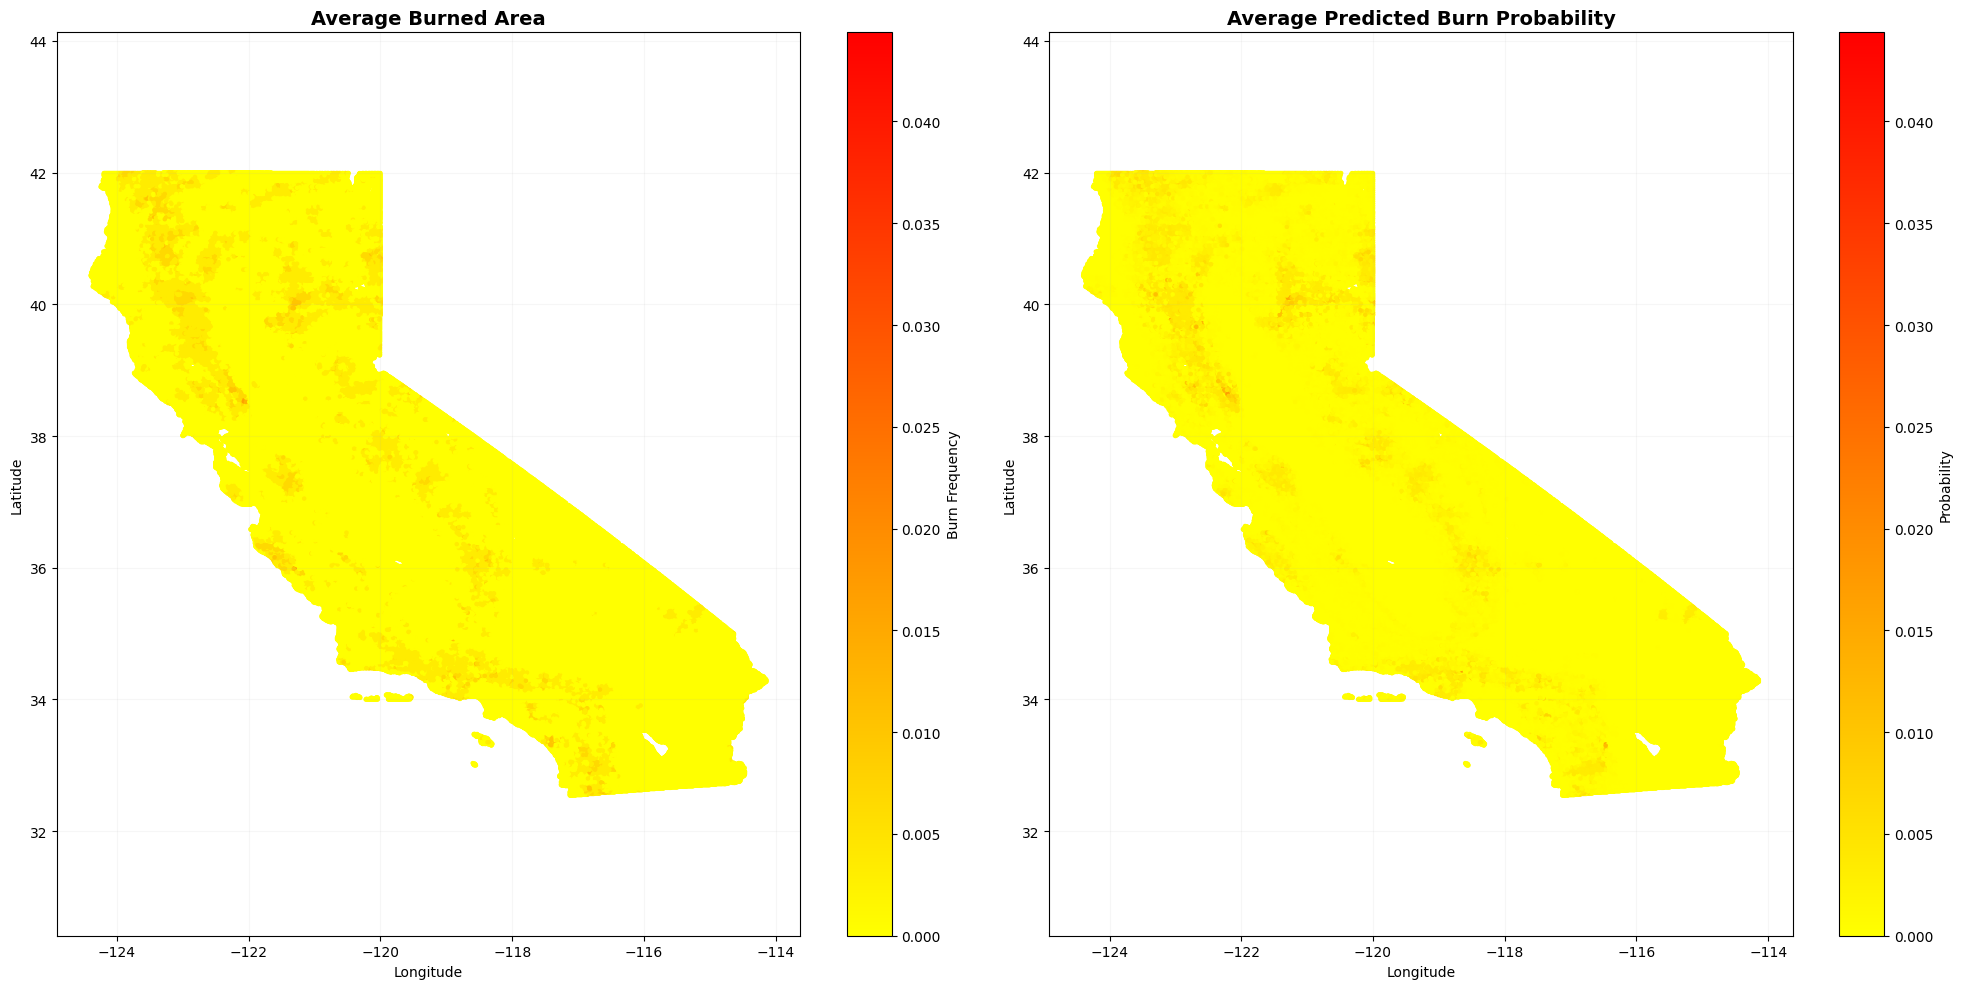

In [21]:
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm

# Use power-law normalization (gamma=0.3) to stretch low/mid values
# This makes differences in important areas more visible
gamma = 0.3

# Create two side-by-side maps with shared color scale
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

cmap = 'autumn_r'

# Plot 1: Average Annual Burned Area
sc1 = axes[0].scatter(
    spatial_avg['lon'],
    spatial_avg['lat'],
    c=spatial_avg['avg_burned_area'],
    cmap=cmap,
    s=5,
    # alpha=0.2,
    vmin = 0,
    vmax = vmax
    # norm=PowerNorm(gamma=gamma, vmin=0, vmax=vmax)
)
axes[0].set_title('Average Burned Area', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
axes[0].grid(True, alpha=0.1)
axes[0].axis('equal')
plt.colorbar(sc1, ax=axes[0], label='Burn Frequency')

# Plot 2: Average Predicted Probability (same color scale)
sc2 = axes[1].scatter(
    spatial_avg['lon'],
    spatial_avg['lat'],
    c=spatial_avg['avg_pred_proba'],
    cmap=cmap,
    s=5,
    # alpha=0.2,
    vmin = 0,
    vmax = vmax
    # norm=PowerNorm(gamma=gamma, vmin=0, vmax=vmax)
)
axes[1].set_title('Average Predicted Burn Probability', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
axes[1].grid(True, alpha=0.1)
axes[1].axis('equal')
plt.colorbar(sc2, ax=axes[1], label='Probability')

plt.tight_layout()
plt.show()

In [25]:
df_full = df_full.with_columns([
    pl.col("year").cast(pl.UInt16),
    pl.col("month").cast(pl.UInt8),
])

# Create output directory
out_dir = Path("website/data/ca")
out_dir.mkdir(parents=True, exist_ok=True)

START = 2025
END = 2026
years = range(START, END)
months = range(1, 13)
combinations = list(itertools.product(years, months))

# df_full = df_full.collect(engine="streaming")

for year, month in tqdm(combinations, desc="Processing slices"):
    out_path = out_dir / f"{year}_{month:02d}.parquet"
    
    # We skip if the file already exists, useful if you want to resume later
    if out_path.exists():
        continue
            
    # Filter, select specific columns, and collect into memory for this slice
    temp_df = (
        df_full
        .filter((pl.col("year") == year) & (pl.col("month") == month))
    )
    
    # If there is data for this month, save it
    if temp_df.height > 0:
        temp_df.write_parquet(out_path, compression='snappy')
        size_mb = os.path.getsize(out_path) / (1024 * 1024)
        # print(f"Saved {out_path} ({size_mb:.2f} MB. Rows: {temp_df.height})")

Processing slices: 100%|██████████| 12/12 [00:00<00:00, 12.98it/s]


In [ ]:
df_full = df_full.with_columns([
    pl.col("year").cast(pl.UInt16),
    pl.col("month").cast(pl.UInt8),
])

df_burned = df_full.filter(
    pl.col('burned_area') == 1
)

df_burned.select(['year', 'month', 'burned_area'])

unique_dates = (
    df_burned
    .group_by(['year', 'month'])
    .agg(
        pl.col("burned_area").sum()
    )
    .sort('burned_area', descending=True)
).collect(engine='streaming')


unique_dates.head(10)

year,month,burned_area
u16,u8,i64
2020,9,17592
2021,8,10528
2008,7,6046
2018,8,5640
2020,10,4722
2003,11,4032
2012,9,3196
2021,9,3110
2015,8,3000


In [34]:
dates_dict = unique_dates[:10].select(['year', 'month']).to_dicts()

with open("ca_burn_dates.json", "w") as f:
    json.dump(dates_dict, f)